In [1]:
# Imports & global style
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from matplotlib.colors import LinearSegmentedColormap


warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="crest")

# Project theme colors (match your presentation)
BG_COLOR = "#E6DED2"
TEXT_COLOR = "#2B2B2B"

# Optional: keep SHAP plots consistent in notebook
plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["axes.facecolor"] = BG_COLOR

In [2]:
# Locate project root + define paths
def find_project_root(start: Path, max_up: int = 6) -> Path:
    """
    Walk upwards to find a folder that contains '1. Data' and '4. Modeling'.
    """
    p = start.resolve()
    for _ in range(max_up):
        if (p / "1. Data").exists() and (p / "4. Modeling").exists():
            return p
        p = p.parent
    # Fallback: current working directory
    return start.resolve()

ROOT = find_project_root(Path.cwd())
DATA_MODEL_READY = ROOT / "1. Data" / "processed" / "weatherAUS_model_ready.csv"
MODEL_PATH = ROOT / "4. Modeling" / "artifacts" / "rf_smote_tuned.joblib"

In [3]:
# Where to save SHAP outputs
FIG_DIR = ROOT / "4. Modeling" / "figures" / "shap"
ART_DIR = ROOT / "4. Modeling" / "artifacts" / "shap"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_MODEL_READY exists:", DATA_MODEL_READY.exists())
print("MODEL_PATH exists:", MODEL_PATH.exists())

DATA_MODEL_READY exists: True
MODEL_PATH exists: True


In [4]:
# Load model-ready dataset (already cleaned/engineered)
df = pd.read_csv(DATA_MODEL_READY)
print("df shape:", df.shape)
df.head()

df shape: (132863, 11)


,Evaporation,Sunshine,WindGustSpeed,WindSpeed,Humidity,Pressure,Cloud,Temperature,WindGustDir,Month,RainTomorrow
0,1.600000,2.6,48.0,14.0,79.5,1017.55,6.0,14.20,NW,Jul,0
1,1.400000,7.8,35.0,14.0,63.5,1022.50,6.0,14.60,SW,Jul,0
2,1.800000,2.1,20.0,6.5,68.5,1027.15,6.0,11.60,W,Jul,0
3,1.400000,8.0,30.0,9.5,58.5,1027.15,6.0,12.75,NNE,Jul,0
4,3.533333,1.5,52.0,18.5,62.0,1017.85,6.0,13.70,NNW,Jul,1


In [5]:
# Build X/y + One-Hot Encode 
X = df.drop(columns=["RainTomorrow"]).copy()
y = df['RainTomorrow'].copy()

In [6]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_ohe = pd.DataFrame(
    ohe.fit_transform(X[["WindGustDir", "Month"]]),
    columns=ohe.get_feature_names_out(["WindGustDir", "Month"]),
    index=X.index)
X_ohe = pd.concat([X.drop(columns=["WindGustDir", "Month"]), X_cat_ohe], axis=1)

In [7]:
# Define numeric vs dummy columns (needed for SHAP naming)
numeric_features = [
    "Evaporation", "Sunshine", "WindGustSpeed",
    "WindSpeed", "Humidity", "Pressure", "Cloud", "Temperature"]
dummy_features = [c for c in X_ohe.columns if c not in numeric_features]
print("X_ohe shape:", X_ohe.shape)
print("Numeric:", len(numeric_features), "| Dummy:", len(dummy_features))

X_ohe shape: (132863, 36)
Numeric: 8 | Dummy: 28


In [8]:
# Create the exact train/test split 
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)
print("X_test shape:", X_test.shape)

X_test shape: (33216, 36)


In [9]:
# This was taking too long with SMOTE in pipeline
"""# Load tuned pipeline artifact (preprocess -> SMOTE -> RF)
tuned_pipe = joblib.load(MODEL_PATH)

pre = tuned_pipe.named_steps["preprocess"]
rf_model = tuned_pipe.named_steps["model"]

print("Preprocess:", type(pre))
print("RF model:", type(rf_model))"""
None

In [10]:
"""# Build a sample for SHAP 
X_sample = X_test.sample(n=min(10, len(X_test)), random_state=42)
X_sample_arr = pre.transform(X_sample)
feature_names = numeric_features + dummy_features
X_sample_model = pd.DataFrame(X_sample_arr, columns=feature_names, index=X_sample.index)
print("X_sample_model shape:", X_sample_model.shape)"""
None

In [11]:
"""# Compute SHAP values + extract class=1
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample_model, check_additivity=False)

if isinstance(shap_values, list):
    # Older SHAP style: list with per-class arrays
    shap_matrix = shap_values[1]  # class 1 = Rain
else:
    # Newer SHAP style: ndarray
    shap_matrix = np.asarray(shap_values)

    # If shape is (n_samples, n_features, 2), take class=1 slice
    if shap_matrix.ndim == 3 and shap_matrix.shape[-1] == 2:
        shap_matrix = shap_matrix[:, :, 1]

print("shap_matrix shape:", shap_matrix.shape)"""
None

In [12]:
# Simple RF just for SHAP
rf_simple = RandomForestClassifier(random_state=42)
rf_simple.fit(X_train, y_train) 
X_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42) 
print("X_sample shape:", X_sample.shape)

X_sample shape: (1000, 36)


In [13]:
explainer = shap.TreeExplainer(rf_simple)
shap_values = explainer.shap_values(X_sample, check_additivity=False)
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]  # class 1 = Rain
else:
    shap_matrix = np.asarray(shap_values)
    if shap_matrix.ndim == 3 and shap_matrix.shape[-1] == 2:
        shap_matrix = shap_matrix[:, :, 1]  # take class 1 slice
print("shap_matrix shape:", np.asarray(shap_matrix).shape)  # should be (n_samples, n_features)

shap_matrix shape: (1000, 36)


In [14]:
# Rank features by mean(|SHAP|) and export
shap_df = pd.DataFrame(shap_matrix, columns=X_sample.columns, index=X_sample.index)
mean_abs = shap_df.abs().mean().sort_values(ascending=False)
shap_rank = mean_abs.reset_index()
shap_rank.columns = ["feature", "mean_abs_shap"]

shap_rank.to_csv(ART_DIR / "shap_rank_full.csv", index=False)
shap_rank.head(20).to_csv(ART_DIR / "shap_rank_top20.csv", index=False)
shap_rank.head(20)

,feature,mean_abs_shap
0,Humidity,0.106087
1,WindGustSpeed,0.052995
2,Pressure,0.047845
3,Sunshine,0.039691
4,Cloud,0.033946
5,Temperature,0.012279
6,Evaporation,0.008836
7,WindSpeed,0.008516
8,WindGustDir_N,0.003377
9,Month_Aug,0.002554


In [15]:
# Helper: apply presentation background to all axes in the current figure
def apply_bg_to_current_figure(bg=BG_COLOR, text=TEXT_COLOR):
    fig = plt.gcf()
    fig.patch.set_facecolor(bg)
    for ax in fig.axes:
        ax.set_facecolor(bg)
        ax.tick_params(colors=text)
        # Some axes (colorbar etc.) may not have labels/titles; guard lightly
        if ax.title is not None:
            ax.title.set_color(text)
        if ax.xaxis.label is not None:
            ax.xaxis.label.set_color(text)
        if ax.yaxis.label is not None:
            ax.yaxis.label.set_color(text)
    plt.tight_layout()


def save_current_fig(filename: str, dpi: int = 220):
    out = FIG_DIR / filename
    plt.savefig(out, dpi=dpi, bbox_inches="tight", facecolor=BG_COLOR)
    print("Saved:", out)

Saved: C:\Users\georg\bigblue_academy\3rd_project_28-02-2026\4. Modeling\figures\shap\shap_beeswarm_top20.png


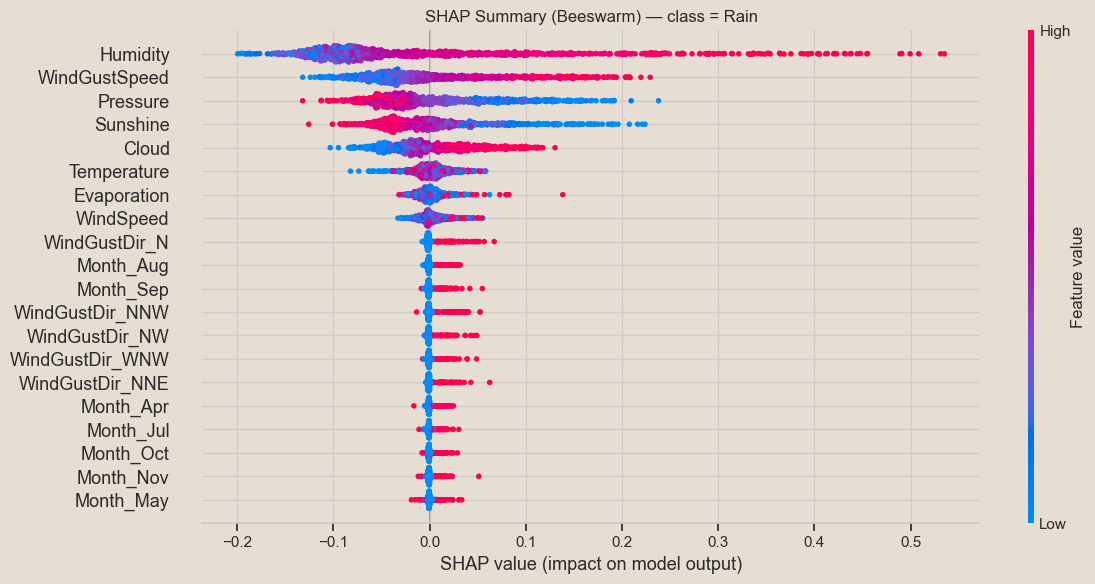

In [16]:
# SHAP plot 1: Beeswarm (top 20) + saved
shap.summary_plot(
    shap_matrix,
    X_sample,
    max_display=20,
    show=False)
plt.gcf().set_size_inches(12, 6)
plt.title("SHAP Summary (Beeswarm) — class = Rain")
apply_bg_to_current_figure()
save_current_fig("shap_beeswarm_top20.png")
plt.show()

Saved: C:\Users\georg\bigblue_academy\3rd_project_28-02-2026\4. Modeling\figures\shap\shap_bar_top20.png


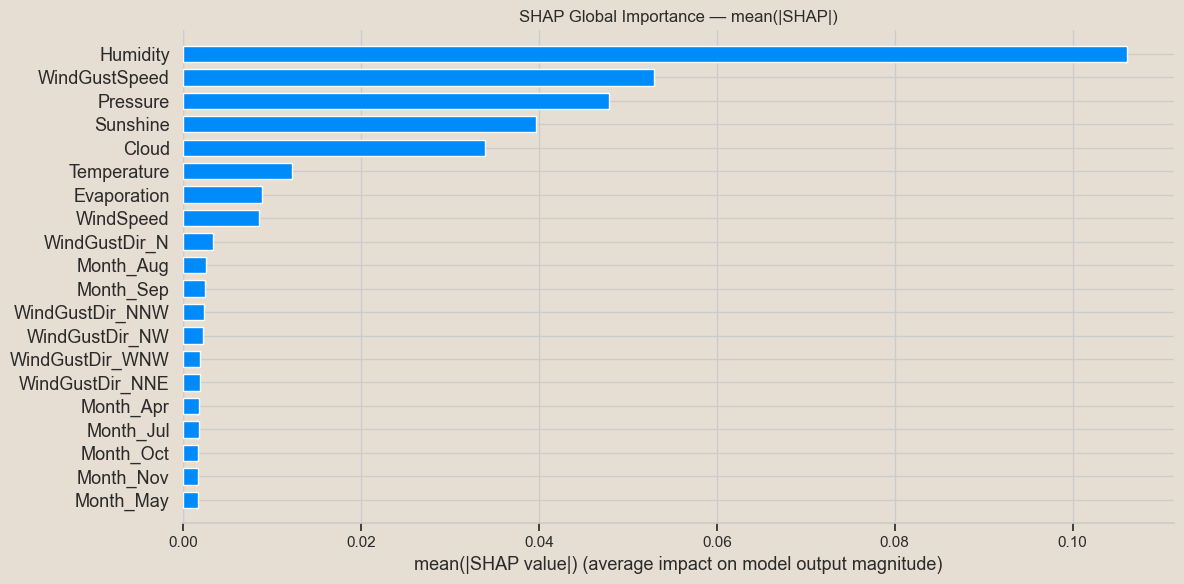

In [17]:
# SHAP plot 2: Bar importance (top 20) + saved
shap.summary_plot(
    shap_matrix,
    X_sample,
    plot_type="bar",
    max_display=20,
    show=False)
plt.gcf().set_size_inches(12, 6)
plt.title("SHAP Global Importance — mean(|SHAP|)")
apply_bg_to_current_figure()
save_current_fig("shap_bar_top20.png")
plt.show()

Saved: C:\Users\georg\bigblue_academy\3rd_project_28-02-2026\4. Modeling\figures\shap\shap_beeswarm_top5_presentation.png


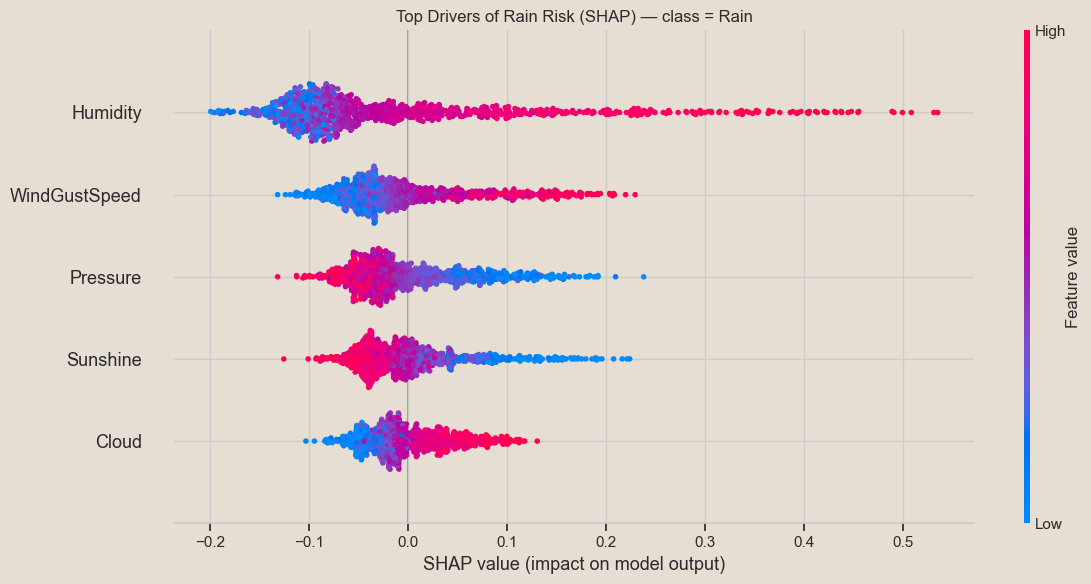

In [18]:
# SHAP plot 3: Presentation beeswarm (top 5) - styled + saved
shap.summary_plot(
    shap_matrix,
    X_sample,
    max_display=5,
    show=False)
plt.gcf().set_size_inches(12, 6)
plt.title("Top Drivers of Rain Risk (SHAP) — class = Rain")
apply_bg_to_current_figure()
save_current_fig("shap_beeswarm_top5_presentation.png")
plt.show()